# Signals

**Disclaimer: portions of the following text have been generated using github CoPilot.The provided information has been validated by expert review.** 

The `pyphysio` package represents physiological signals primarily using the `xarray.DataArray` structure, which provides a powerful and flexible way to handle multidimensional data with labeled dimensions and coordinates. Here's an overview of how signals are implemented:

### 1. **Signal Creation**
The `create_signal` function is the primary method for creating signals. It takes raw data (a NumPy array), along with optional parameters like time values, sampling frequency, start time, and metadata (`info`), and wraps it into an `xarray.DataArray`. Key features include:
- **Dimensions and Coordinates**: The function assigns labeled dimensions (`time`, `channel`, `component`, etc.) and coordinates (e.g., time values) to the data.
- **Attributes**: Metadata such as sampling frequency and start time are stored as attributes of the `DataArray`.

### 2. **Signal Accessor**
The `pyphysio` package extends the functionality of `xarray.DataArray` by registering a custom accessor, `PyphysioDataArray`, under the `.p` namespace. This accessor provides methods for signal-specific operations, such as:
- **Cloning**: The `clone` method creates a new signal with modified values while preserving metadata.
- **Data Access**: Methods like `get_values` and `get_times` retrieve the signal's data and time values, respectively.
- **Signal Properties**: Methods like `get_start_time`, `get_end_time`, `get_sampling_freq`, and `get_duration` provide information about the signal's temporal properties.
- **Signal Manipulation**: Methods like `segment_time` and `resample` allow for segmenting and resampling the signal.

### 3. **Signal Loading**
The package provides functions for loading signals from various file formats. For example:
- `load_xdf` loads signals from XDF files.
- `load_biopac` loads signals from Biopac files.
- `load_snirf` loads signals from snirf files.

These functions often use the `create_signal` function to wrap the loaded data into an `xarray.DataArray`.

### 5. **Signal Processing**
The `PyphysioDataArray` accessor includes methods for processing signals, such as handling NaN values (`process_na`) and plotting signals (`plot`). These methods leverage the capabilities of `xarray` for efficient data manipulation.

### Summary
The `pyphysio` package uses `xarray.DataArray` as the core data structure for signals, enriched with custom methods and attributes for physiological signal processing. It provides a modular and extensible framework for creating, loading, manipulating, and analyzing signals.

In [1]:
# import packages
import numpy as np
import matplotlib.pyplot as plt

%matplotlib ipympl

In [2]:
from pyphysio import create_signal # to create signals

Using dask. Scheduler: threads
Please cite:
Bizzego et al. (2019) 'pyphysio: A physiological signal processing library for data science approaches in physiology', SoftwareX


### 1.1 Evenly sampled signal

When the signal is sampled with a fixed sampling frequency it is sufficient to know the timestamp at which the acquisition started and the sampling frequency (assumed to be constant) to reconstruct the timestamp of each sample.

Therefore to create an *evenly sampled signal** these are the input parameters needed:
* ``values`` : values of the signal;
* ``sampling_freq`` : (float>0) sampling frequency;
* ``start_time`` : (float) temporal reference of the start of the signal. This is optional, if omitted it will set to 0;
* ``info`` : (dict) dictionary that will contain general (custom) information about the signal.

Some functions are provided to facilitate the management and processing of signals. To access them you need to use `.p` namespace.
* `.p.get_...()` type functions can be used to get some signal properties;
* `.p.plot()` will plot the signal using matplotlib;
* `.p.segment_time(t_start, t_stop)` a portion of the signal between a given interval;
* `.p.resample(fout)` can be used to change the sampling frequency.

`xarray.DataArray` methods can also be used to manipulate the data and access data values (e.g. select a specific channel: `.sel({'channel': [4]})`.

#### 1.1.1 Creation of an *evenly sampled* signal

In the following we generate a fake evenly samples signal using random generated numbers. Then we will use the methods provided by the class to inspect the signal characteristics:

In [3]:
# create a signal

## create fake data
np.random.seed(4)
signal_values = np.random.uniform(0, 1, size = 1000) # create a simple signal

## set the sampling frequency
fsamp = 100 # Hz

## set the starting time
tstart = 10 # s

## create the signal
signal = create_signal(data = signal_values, 
                       sampling_freq = fsamp, start_time = tstart, 
                       info  = {'type': 'fake', 'subject': 'SUB001'})

# chech signal properties
print('Sampling frequency: {}'.format( signal.p.get_sampling_freq() ))
print('Start time:         {}'.format( signal.p.get_start_time() ))
print('End time:           {}'.format( signal.p.get_end_time() ))
print('Duration:           {}'.format( signal.p.get_duration() ))
print('Signal info  :      {}'.format( signal.p.get_info() ))
print('First ten instants: {}'.format( signal.p.get_times()[0:10] ))

Sampling frequency: 100.0
Start time:         10.0
End time:           19.990000000000002
Duration:           9.990000000000002
Signal info  :      {'type': 'fake', 'subject': 'SUB001', 'sampling_freq': 100.0, 'start_time': 10.0}
First ten instants: [10.   10.01 10.02 10.03 10.04 10.05 10.06 10.07 10.08 10.09]


#### 1.1.2 Plotting a signal

A function is provided in the `.p` namespace to plot a signal, using the `matplotlib` library:

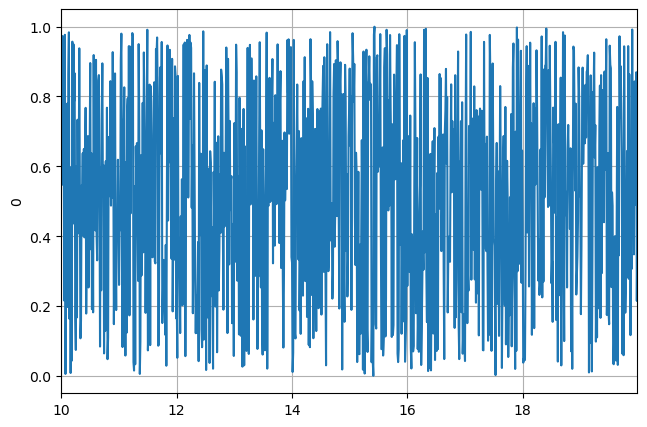

In [4]:
## plot
signal.p.plot()

#### 1.1.3 Creating a multi-channel / multi-component signal

`pyphysio` supports signals with multiple channels and components (e.g. fNIRS).

The names of the signal dimensions will be automatically assigned based on the following names: ('time', 'channel', 'component', 'dimension_4', 'dimension_5', ..., 'dimension_N')


In [5]:
n_timepoints = 1000;
n_channels = 20;
n_components = 2;

signal_values = np.random.uniform(0, 1, size = (n_timepoints, n_channels, n_components))
signal_values = signal_values + np.random.uniform(0, 20, size = (1, n_channels, n_components)) # add random mean

signal_multi = create_signal(data = signal_values, 
                             sampling_freq = fsamp, start_time = tstart) #info is an optional parameter


print('Sampling frequency: {}'.format( signal_multi.p.get_sampling_freq() ))
print('Start time:         {}'.format( signal_multi.p.get_start_time() ))
print('End time:           {}'.format( signal_multi.p.get_end_time() ))
print('Duration:           {}'.format( signal_multi.p.get_duration() ))
print('Signal info  :      {}'.format( signal_multi.p.get_info() ))
print('First ten instants: {}'.format( signal_multi.p.get_times()[0:10] ))

print('Multi-channel?:     {}'.format( signal_multi.p.has_multi_channels() ))
print('N channels:         {}'.format( signal_multi.p.get_nchannels() ))
print('Multi-components? : {}'.format( signal_multi.p.has_multi_components()  ))
print('N components:       {}'.format( signal_multi.p.get_ncomponents()  ))





Sampling frequency: 100.0
Start time:         10.0
End time:           19.990000000000002
Duration:           9.990000000000002
Signal info  :      {'sampling_freq': 100.0, 'start_time': 10.0}
First ten instants: [10.   10.01 10.02 10.03 10.04 10.05 10.06 10.07 10.08 10.09]
Multi-channel?:     True
N channels:         20
Multi-components? : True
N components:       2


The `.p.plot()` function can be used to plot signals with up to 3 dimensions.

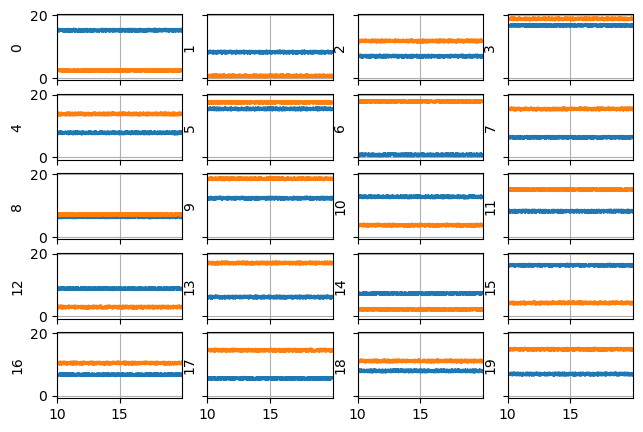

In [6]:
signal_multi.p.plot(sharey=True)

### 1.2 Unevenly sampled signal

`pyphysio` supports signals with a non fixed sampling frequency, for instance triggers or events. 

For these signals you need to provide the timestamps of the individual datapoints, using the `times` parameter.

In [7]:
times = [10.5, 20, 55]
n_channels = 20;
n_components = 2;

signal_values = np.random.uniform(0, 1, size = (len(times), n_channels, n_components))
signal_values = signal_values + np.random.uniform(0, 20, size = (1, n_channels, n_components)) # add random mean

signal_unevenly = create_signal(data = signal_values, 
                             times = times)

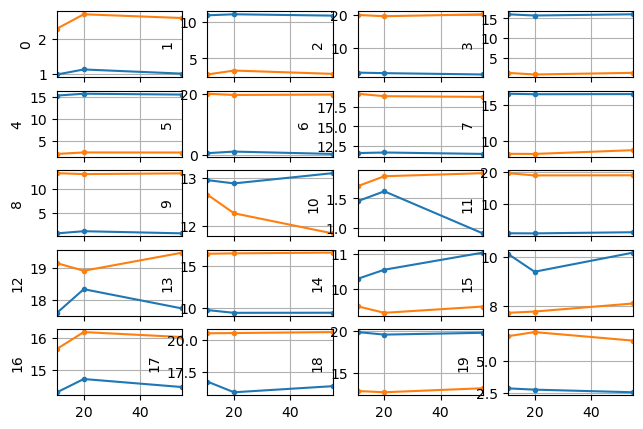

In [8]:
signal_unevenly.p.plot()

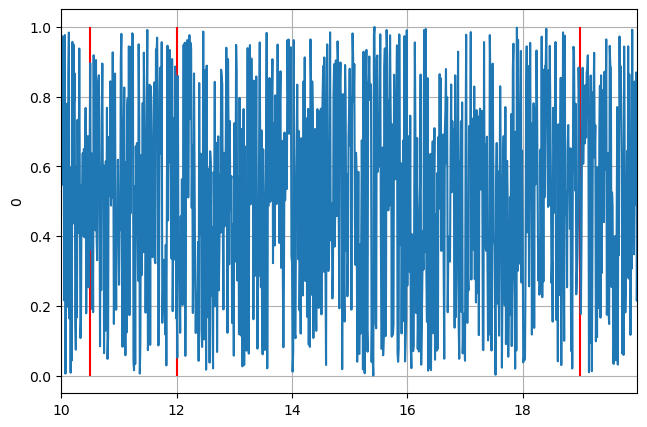

In [9]:
#create a trigger signal and plot it with other signals
times = [10.5, 12, 19]
values = np.ones(len(times))

trigger = create_signal(values, times=times)

trigger.p.plot('|', color = 'red') #plotting vertical bars to show the trigger position
signal.p.plot()


### 1.3 Segmentation of signals

`segment_time(t_start, t_stop)` is used to extract a portion of the signal between the instants `t_start` and `t_stop`

In [10]:
# segmentation of ES
signal_segment = signal.p.segment_time(12, 15)

12.0 15.0


/mnt/raidpool/UniTn/software/pyphysio/pyphysio/signal.py:567: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r" (-> color=(1.0, 0.0, 0.0, 1)). The keyword argument will take precedence.
  ax.plot(t_, v_current, marker, linestyle = linestyle, color=color)


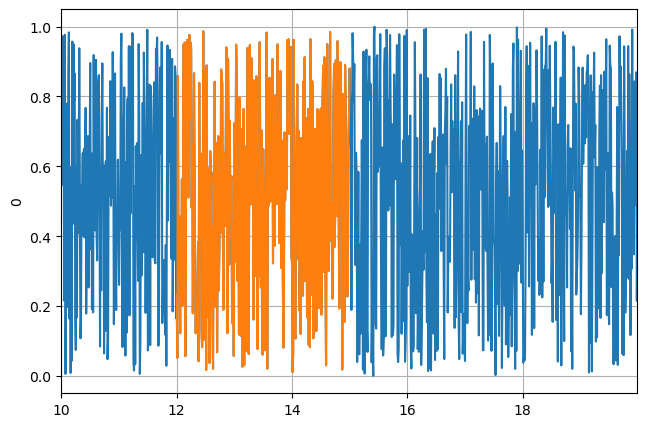

In [11]:
# plot
signal.p.plot()
signal_segment.p.plot('r')
plt.xlim(signal.p.get_start_time(), signal.p.get_end_time());

print(signal_segment.p.get_start_time(), signal_segment.p.get_end_time())